# Data augmentation

m3's decoder is generative: by sampling the trained model we can synthesise new
**donors** (for augmenting small cohorts) and new **cells**. This tutorial makes
synthetic donors per condition with `model.augment()`, checks they match the real
data, and resamples cells with `model.generate()`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import m3

OUT = "./tutorial_out_demo/04_augmentation"
os.makedirs(OUT, exist_ok=True)

## 1. Load the demo data

In [2]:
data = m3.datasets.liu_demo()
print(data)

Dataset(n_cells=30534, batches=['B1', 'B2', 'B3'], modalities=[rna:1000, adt:192])


/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 2. Build and train the model

Augmentation only needs the generator, so we skip the donor predictor
(`donor_prediction=False`) to save time. `donor_key` is still set because the
batch column drives the batch-stratified augmentation in the check below.

In [3]:
model = m3.M3(
    data,
    condition_keys=["cond_group", "Age_interval"],
    target_condition="cond_group",
    celltype_key="mergedcelltype",
    batch_key="batch",
    donor_key="sample_id",
    embedding_dim=30,
)
model.train(max_epochs=500, donor_prediction=False)

Using 'matrix/data'
torch.Size([1000, 7163])
Using 'matrix/data'


torch.Size([1000, 10789])
Using 'matrix/data'
torch.Size([1000, 12582])
Using 'matrix/data'


torch.Size([192, 7163])
Using 'matrix/data'
torch.Size([192, 10789])
Using 'matrix/data'
torch.Size([192, 12582])
Batch counts: {0: 7163, 1: 10789, 2: 12582}
Minimum batch size: 7163


Epoch 1, Validation Loss: 5.1807


Epoch 2, Validation Loss: 5.1167


...

Epoch 498, Validation Loss: 0.5032


Epoch 499, Validation Loss: 0.5039


Epoch 500, Validation Loss: 0.5011
Using 'matrix/data'
torch.Size([1000, 7163])
Using 'matrix/data'


torch.Size([1000, 10789])
Using 'matrix/data'
torch.Size([1000, 12582])
Using 'matrix/data'


torch.Size([192, 7163])
Using 'matrix/data'
torch.Size([192, 10789])
Using 'matrix/data'
torch.Size([192, 12582])


## 3. Synthesize new donors

`model.augment(...)` samples the trained model to create brand-new synthetic
donors for the conditions you ask for. It returns a dict with `expression`
(per-modality synthetic cells) and `obs` (their condition and donor labels).

- `conditions` / `n_donors`: which conditions to synthesise, and how many new
  donors for each.
- `batch`: draw templates from one batch only, so the new donors carry that
  batch's character (used in the check below); omit it to draw from all batches.

In [4]:
aug = model.augment(conditions=["HC", "Severe"], n_donors=[3, 3], tau=0.8)
syn_rna = aug["expression"]["rna"]
syn_obs = aug["obs"]
print("synthetic cells:", syn_rna.shape, "per condition:")
print(syn_obs.groupby("cond_group").size().to_string())

synthetic cells: (3501, 1000) per condition:
cond_group
HC        2609
Severe     892


## 4. Save the synthetic donors

The synthetic expression and labels, in the three formats from the
representation-learning tutorial.

In [5]:
import h5py
import anndata as ad

syn_obs.to_csv(os.path.join(OUT, "synthetic_obs.csv"), index=False)
np.save(os.path.join(OUT, "synthetic_rna.npy"), syn_rna)
with h5py.File(os.path.join(OUT, "synthetic_rna.h5"), "w") as f:
    f["data"] = syn_rna
ad.AnnData(X=syn_rna, obs=syn_obs.astype(str).reset_index(drop=True),
           var=pd.DataFrame(index=list(data.var["rna"]))).write_h5ad(
    os.path.join(OUT, "synthetic.h5ad"))
print("saved synthetic -> .npy / .h5 (['data']) / .h5ad in", OUT)

/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
... storing 'cond_group' as categorical


... storing 'mergedcelltype' as categorical


... storing 'sample_id' as categorical


... storing 'simulate' as categorical


saved synthetic -> .npy / .h5 (['data']) / .h5ad in ./tutorial_out_demo/04_augmentation


## 5. Check against the real data

Do the synthetic donors look like real ones? We compare in the model's
reconstruction space (where the synthetic cells live), so real and generated
donors of the same condition should line up.

In [6]:
# Reconstruct the real cells once, then a quick sanity number: the per-gene mean
# expression of real vs synthetic should correlate almost perfectly.
recon = model.reconstruct(remove_batch=False)
real_rna_all = np.nan_to_num(np.asarray(recon["rna"], dtype=np.float32))
real_adt_all = np.nan_to_num(np.asarray(recon["adt"], dtype=np.float32))
pearson = float(np.corrcoef(real_rna_all.mean(0), np.nan_to_num(syn_rna).mean(0))[0, 1])
print(f"per-gene mean expression Pearson r = {pearson:.3f}")

per-gene mean expression Pearson r = 0.998


A UMAP per batch and modality, one dot per sample. Each sample is summarised by
its mean expression **within every cell type shared by all samples** (the
per-cell-type means concatenated into one vector), so differences in cell-type
composition don't confound the comparison; features are then standardised. Real
donors are open circles, M3-generated donors are crosses, and colour marks the
condition. Synthetic samples should sit with the real samples of the same
condition in the same batch.

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler

COLORS = {"HC": "#E64B35", "Severe": "#4DBBD5"}


def celltype_pseudobulk(X, samples, celltypes):
    """One row per sample: mean expression within each cell type shared by all
    samples, concatenated. Comparing per cell type keeps composition out of it."""
    keys = pd.unique(samples)
    shared = sorted(set.intersection(*(set(celltypes[samples == k]) for k in keys)))
    rows = [np.concatenate([X[(samples == k) & (celltypes == c)].mean(0) for c in shared])
            for k in keys]
    return np.vstack(rows), keys


def embed_2d(pb):
    """Standardise each feature, then a Euclidean UMAP of the samples."""
    return umap.UMAP(n_neighbors=min(10, pb.shape[0] - 1), min_dist=0.3,
                     random_state=0).fit_transform(StandardScaler().fit_transform(pb))


def draw_panel(ax, xy, conds, is_real):
    """Real samples as open circles, generated as crosses, coloured by condition."""
    for cond, color in COLORS.items():
        real = (conds == cond) & is_real
        ax.scatter(xy[real, 0], xy[real, 1], facecolors="none", edgecolors=color, s=80, linewidths=1.5)
        syn = (conds == cond) & ~is_real
        ax.scatter(xy[syn, 0], xy[syn, 1], marker="x", c=color, s=80, linewidths=2)
    ax.set_xticks([])
    ax.set_yticks([])

2026-07-14 15:23:33.918307: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-14 15:23:34.534736: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


**Embed** each batch and modality: augment on that batch, then pseudobulk and UMAP
the real + synthetic samples together into one 2D layout per panel.

In [ ]:
# real and synthetic cells share the same obs keys: sample_id (donor), cond_group,
# and mergedcelltype.
real_meta = model.cell_metadata[["sample_id", "cond_group", "batch", "mergedcelltype"]].astype(str).reset_index(drop=True)
real_by_mod = {"RNA": real_rna_all, "ADT": real_adt_all}
batches = sorted(real_meta["batch"].unique())
N_DONORS = 5

panels = []   # one entry per (batch, modality): its 2D layout + sample labels
for col, batch in enumerate(batches):
    in_batch = (real_meta["batch"] == batch).to_numpy()
    real = real_meta.loc[in_batch]

    # augment templated on THIS batch, so the synthetic donors carry its character
    ag = model.augment(conditions=["HC", "Severe"], n_donors=[N_DONORS, N_DONORS],
                       batch=batch, tau=0.8, seed=42 + col)
    syn = ag["obs"].astype(str)

    # per-cell labels for this batch's real + synthetic samples
    samples = np.concatenate([real["sample_id"].to_numpy(),
                              (syn["cond_group"] + "/" + syn["sample_id"]).to_numpy()])
    celltypes = np.concatenate([real["mergedcelltype"].to_numpy(), syn["mergedcelltype"].to_numpy()])
    cond_of = dict(zip(samples, np.concatenate([real["cond_group"].to_numpy(), syn["cond_group"].to_numpy()])))
    real_of = dict(zip(samples, np.concatenate([np.full(len(real), True), np.full(len(syn), False)])))

    for row, modname in enumerate(["RNA", "ADT"]):
        X = np.vstack([real_by_mod[modname][in_batch], ag["expression"][modname.lower()]])
        pb, keys = celltype_pseudobulk(X, samples, celltypes)
        conds = np.array([cond_of[k] for k in keys])
        is_real = np.array([real_of[k] for k in keys])
        panels.append(dict(row=row, col=col, batch=batch, modname=modname,
                           xy=embed_2d(pb), conds=conds, is_real=is_real))

/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


**Draw** the panels: real donors as open circles, M3-generated as crosses, colour
marks the condition, with a shared legend in a spare right-hand column.

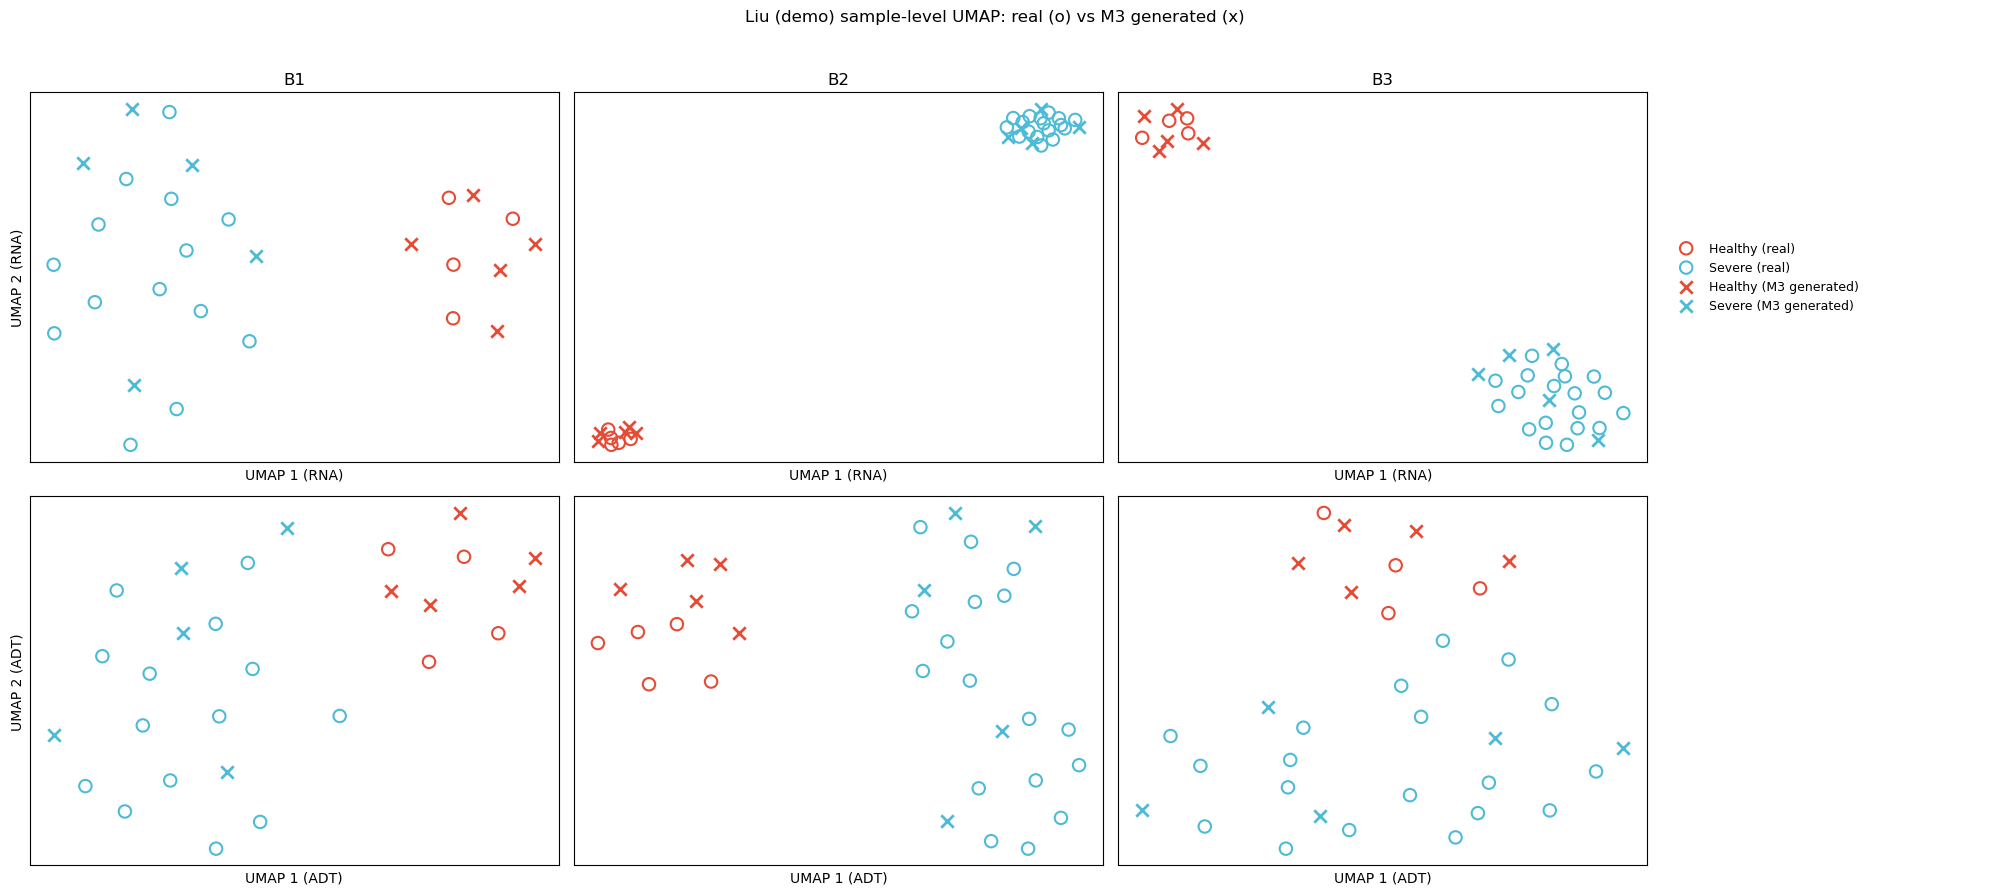

In [ ]:
fig, axes = plt.subplots(2, len(batches) + 1, figsize=(5 * (len(batches) + 1), 9),
                         squeeze=False, gridspec_kw=dict(width_ratios=[1] * len(batches) + [0.6]))
fig.suptitle("Liu (demo) sample-level UMAP: real (o) vs M3 generated (x)", y=0.99)

for p in panels:
    ax = axes[p["row"], p["col"]]
    draw_panel(ax, p["xy"], p["conds"], p["is_real"])
    if p["row"] == 0:
        ax.set_title(p["batch"])
    ax.set_xlabel(f"UMAP 1 ({p['modname']})")
    if p["col"] == 0:
        ax.set_ylabel(f"UMAP 2 ({p['modname']})")

for ax in axes[:, -1]:
    ax.axis("off")
legend_ax = axes[0, -1]
legend_ax.scatter([], [], facecolors="none", edgecolors="#E64B35", s=80, linewidths=1.5, label="Healthy (real)")
legend_ax.scatter([], [], facecolors="none", edgecolors="#4DBBD5", s=80, linewidths=1.5, label="Severe (real)")
legend_ax.scatter([], [], marker="x", c="#E64B35", s=80, linewidths=2, label="Healthy (M3 generated)")
legend_ax.scatter([], [], marker="x", c="#4DBBD5", s=80, linewidths=2, label="Severe (M3 generated)")
legend_ax.legend(loc="center left", frameon=False, fontsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(os.path.join(OUT, "real_vs_synthetic_samplelevel.png"), dpi=130, bbox_inches="tight")
plt.show()

## 6. Posterior-resampled cells

`model.generate(...)` returns one synthetic cell per real cell (a 1:1 posterior
resample), handy for noise-augmenting a training set at the cell level.

In [8]:
gen = model.generate(tau=0.8)
print("generated:", {k: v.shape for k, v in gen.items()})
np.save(os.path.join(OUT, "generated_rna.npy"), gen["rna"])

generated: {'rna': (30534, 1000), 'adt': (30534, 192)}


**Done.** Synthetic donors per condition (checked against the real data) plus a
1:1 posterior resample of the cells.